# Bias and Fairness Audit

This notebook conducts a structured bias and fairness audit of the NovaCred credit application dataset used in automated loan decision-making. The objective is to evaluate whether NovaCred's historical credit decisions exhibit systematic disparities with respect to protected characteristics (gender, age) or operate through discriminatory proxy variables (ZIP code, spending behaviour).

This notebook represents the detailed technical analysis for the **bias and fairness pillar** of the governance audit. While the README consolidates overall conclusions across all governance dimensions, this document provides the structured findings, risk assessments, and recommended controls underlying those conclusions.

**Important scope note:** This is an audit of **historical decision outcomes** — not an evaluation of a retrained predictive model. All fairness metrics are computed on NovaCred's actual approval and pricing decisions as recorded in the dataset.

## Table of Contents

1. [Executive Summary](#1-executive-summary)
2. [Audit Framework](#2-audit-framework)
3. [Methodological Principles](#3-methodological-principles)
4. [Data Loading and Age Derivation](#4-data-loading-and-age-derivation)
5. [Baseline Disparity Analysis](#5-baseline-disparity-analysis)
   - 5.1 [Gender — Approval Rates and Disparate Impact](#51-gender--approval-rates-and-disparate-impact)
   - 5.2 [Age — Approval Rates](#52-age--approval-rates)
   - 5.3 [Baseline Disparity Risk Assessment](#53-baseline-disparity-risk-assessment)
6. [Conditional Fairness Analysis](#6-conditional-fairness-analysis)
   - 6.1 [Gender — Conditional Approval](#61-gender--conditional-approval)
   - 6.2 [Age — Conditional Approval](#62-age--conditional-approval)
   - 6.3 [Conditional Fairness Risk Assessment](#63-conditional-fairness-risk-assessment)
7. [Pricing Fairness](#7-pricing-fairness)
   - 7.1 [Descriptive Interest Rate Comparison](#71-descriptive-interest-rate-comparison)
   - 7.2 [Conditional Pricing Analysis](#72-conditional-pricing-analysis)
   - 7.3 [Pricing Risk Assessment](#73-pricing-risk-assessment)
8. [Proxy Discrimination Risk](#8-proxy-discrimination-risk)
   - 8.1 [ZIP Code as Geographic Proxy](#81-zip-code-as-geographic-proxy)
   - 8.2 [Spending Behaviour as Demographic Proxy](#82-spending-behaviour-as-demographic-proxy)
   - 8.3 [Proxy Discrimination Risk Assessment](#83-proxy-discrimination-risk-assessment)
9. [Intersectional Effects](#9-intersectional-effects)
   - 9.1 [Gender × Age Group Analysis](#91-gender--age-group-analysis)
   - 9.2 [Intersectional Risk Assessment](#92-intersectional-risk-assessment)
10. [Fairlearn Metrics Summary](#10-fairlearn-metrics-summary)
11. [Consolidated Risk Assessment](#11-consolidated-risk-assessment)
12. [Governance Actions and Recommended Controls](#12-governance-actions-and-recommended-controls)
13. [Bias Remediation](#13-bias-remediation)


## 1. Executive Summary

**Overall fairness risk classification: CRITICAL**

This audit evaluated 500 credit application records from NovaCred's automated loan decision system across four analytical layers: baseline disparity, conditional fairness, pricing fairness, and proxy discrimination. All analyses are conditioned on a fixed reference date (2025-12-31) and use financial controls (annual income, debt-to-income ratio, credit history, savings balance) to distinguish legitimate risk-driven patterns from discriminatory treatment.

---

### Key Findings

**1. Gender Discrimination — CRITICAL**
Female applicants are approved at a rate of 50.6% (127/251) versus 66.0% (163/247) for male applicants, yielding a Disparate Impact ratio of **0.77** — below the EEOC four-fifths threshold of 0.80 (chi² = 11.51, p = 0.0007). Critically, this disparity **persists in full after controlling for all financial risk variables**: the conditional logistic regression returns an odds ratio of **OR = 1.98** (95% CI: 1.36–2.89) for male applicants, with Wald test p = 0.0004. Male applicants with identical income, debt levels, credit history, and savings are nearly twice as likely to be approved as comparable female applicants. This constitutes direct evidence of discriminatory decisioning under GDPR Article 22 and EU AI Act Annex III.

**2. Intersectional Effects — HIGH**
Three gender × age subgroups show four-fifths rule violations: female applicants aged 26–35 (DI = **0.620**, worst case), 18–25 (DI = 0.769), and 51–65 (DI = 0.760). The overall gender DI of 0.77 understates the severity of compounded disadvantage within specific age bands. Subgroup-level monitoring is mandatory under EU AI Act Annex III.

**3. ZIP Code — HIGH (Data Minimisation Violation)**
ZIP code is near-perfectly collinear with gender: NYC (10xxx) applicants are 88.8% male; LA (90xxx) applicants are 93.5% female (chi² = 324.67, p < 0.001). The Condition 2 test shows that ZIP does not independently predict approval after controlling for gender and financials (OR = 1.14, p = 0.67) — active proxy discrimination is not confirmed, but retaining ZIP in any model violates the GDPR data minimisation principle (Art. 5(1)(c)) and creates high risk of encoding gender discrimination in future model iterations.

**4. Age Discrimination — MODERATE**
Approval rates vary by age group from 43.5% (18–25) to 67.4% (36–50) (Kruskal-Wallis H = 16.27, p = 0.003). After financial controls, age is **not independently predictive** of approval (OR = 1.00, p = 0.72), suggesting observed age disparities reflect differences in applicants' financial risk profiles rather than direct age discrimination. Non-linear and intersectional age effects remain a monitoring concern.

**5. Pricing Fairness — LOW**
Male approved applicants pay 4.63% interest versus 4.49% for female approved applicants — a gap of +0.14 pp. Neither the descriptive Welch t-test (p = 0.313) nor the conditional OLS regression (β = +0.15 pp, p = 0.288) detects a statistically significant pricing disparity. No pricing discrimination is evidenced in current data.

**6. Sensitive Spending Data — MODERATE (GDPR Concern)**
Spending categories for gambling, adult entertainment, and alcohol are present in the dataset with insufficient sample sizes for proxy testing. Their collection without demonstrated credit-decision necessity likely violates GDPR Article 9 and the data minimisation principle.

---

### Immediate Actions Required

| Priority | Action | Basis |
|----------|--------|-------|
| **Critical** | Suspend automated approvals; conduct root-cause model audit for gender bias (OR = 1.98) | GDPR Art. 22; EU AI Act |
| **Critical** | Remove ZIP code from all model inputs immediately | GDPR Art. 5(1)(c) |
| **High** | Remediate intersectional disparities for female 26–35, 18–25, and 51–65 subgroups | EU AI Act Annex III |
| **Short-term** | DPO review of sensitive spending categories | GDPR Art. 9 |
| **Ongoing** | Implement monthly disaggregated DI monitoring (gender, age, gender × age) | EU AI Act Art. 9 |

## 2. Audit Framework

The bias and fairness assessment is structured along four analytical layers:

1. **Baseline disparity** — Whether protected groups (gender, age) experience materially different approval rates, quantified using the Disparate Impact ratio and standard statistical tests.
2. **Conditional fairness** — Whether observed disparities persist after controlling for legitimate financial risk factors, assessed through logistic regression (approval) and OLS regression (interest rate).
3. **Proxy discrimination** — Whether non-protected features (ZIP code, spending categories) function as discriminatory proxies by being simultaneously correlated with protected attributes and predictive of outcomes.
4. **Intersectional effects** — Whether compounded disadvantage arises at the intersection of multiple protected attributes (gender × age).

For each identified finding, we report:

| Attribute | Description |
|---|---|
| Affected records | Count and percentage of dataset |
| Severity | Low · Moderate · High · Critical |
| Governance impact | Effect on decision integrity, regulatory compliance, or applicant rights |
| Recommended control | Corrective or monitoring measures |

Issues are classified using the following severity scale:

| Level | Definition |
|---|---|
| **Low** | Minor disparity; no regulatory threshold crossed |
| **Moderate** | Statistically significant disparity; limited material impact; threshold not crossed |
| **High** | Regulatory threshold violated (e.g., DI < 0.80) or strong proxy signal detected |
| **Critical** | Disparity persists after controlling for financial risk factors — direct evidence of discriminatory decisioning |

**Fairness thresholds applied:**

| Metric | Threshold | Regulatory Basis |
|--------|-----------|------------------|
| Disparate Impact (DI) ratio | < 0.80 = potential disparate impact | EEOC Uniform Guidelines (four-fifths rule) |
| Demographic Parity Difference | \|DPD\| > 0.10 = meaningful concern | Fairlearn / EU AI Act guidance |
| Statistical significance | p < 0.05 (two-sided) | Standard null-hypothesis testing |
| Conditional disparity | p < 0.05 after financial controls | Elevated severity (Critical) |

## 3. Methodological Principles

| Principle | Description |
|---|---|
| **Reproducibility** | All computations use fixed reference points (e.g., `REFERENCE_DATE = 2025-12-31` for age derivation rather than `pd.Timestamp("today")`) |
| **Quantification** | Findings are expressed in both absolute counts and percentages; effect sizes and confidence intervals are reported alongside p-values |
| **Two-stage analysis** | Descriptive disparity is distinguished from conditional disparity — a finding is elevated to Critical only when it survives logistic or OLS regression with financial controls |
| **Structured reporting** | Each assessment section concludes with a standardised risk assessment table summarising findings, evidence, severity, governance impact, and recommended controls |
| **Conservative proxy standard** | Proxy discrimination requires satisfying two conditions simultaneously: (1) feature correlated with protected attribute, and (2) feature predicts outcome after controls. Condition 1 alone warrants data-minimisation action |

## 4. Data Loading and Age Derivation

The cleaned dataset from `01-data-quality.ipynb` is loaded directly. All structural data quality issues (gender encoding, date formats, income dtype, duplicates, invalid credit history) were resolved upstream.

The only step performed here is deriving `age` and `age_group` from the already-parsed `date_of_birth` — this is specific to the bias analysis and is not part of the data quality pipeline.

In [1]:
# importing necessary libraries and modules
import sys
import os
import warnings
warnings.filterwarnings("ignore")

sys.path.append(os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from fairlearn.metrics import demographic_parity_difference, MetricFrame, selection_rate

# reproducibility seed
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 80)

# fixed reference date for age computation — never use pd.Timestamp("today")
REFERENCE_DATE = pd.Timestamp("2025-12-31")

# fairness thresholds
DI_THRESHOLD  = 0.80   # EEOC four-fifths rule
ALPHA         = 0.05   # significance level (two-sided)
DPD_THRESHOLD = 0.10   # Fairlearn demographic parity difference concern threshold

# financial control variables used in all regression models
FINANCIAL_CONTROLS = ["annual_income_num", "debt_to_income", "credit_history_months", "savings_balance"]

In [2]:
# helper: logistic regression with Wald-test p-values (sklearn + numpy + scipy)
# statsmodels is not in the project environment, so we compute Wald statistics
# directly from the observed Fisher information matrix
def logistic_coef_stats(X_arr, y_arr, feature_names):
    # coerce to float64 so numpy linear algebra ops work regardless of pandas dtypes
    X_arr = np.asarray(X_arr, dtype=np.float64)
    y_arr = np.asarray(y_arr, dtype=np.float64)
    model = LogisticRegression(max_iter=2000, random_state=RANDOM_SEED, solver="lbfgs", C=1e9)
    model.fit(X_arr, y_arr)
    p_hat = model.predict_proba(X_arr)[:, 1]
    X_des = np.column_stack([np.ones(len(X_arr)), X_arr])
    w = p_hat * (1.0 - p_hat)
    H = (X_des.T * w) @ X_des
    try:
        cov = np.linalg.inv(H)
        se  = np.sqrt(np.maximum(np.diag(cov), 0.0))
    except np.linalg.LinAlgError:
        se = np.full(X_des.shape[1], np.nan)
    coefs = np.concatenate([[model.intercept_[0]], model.coef_[0]])
    z     = coefs / se
    pvals = 2.0 * stats.norm.sf(np.abs(z))
    return pd.DataFrame({
        "feature":    ["intercept"] + list(feature_names),
        "coef":       coefs.round(4),
        "odds_ratio": np.exp(coefs).round(4),
        "std_err":    se.round(4),
        "z_score":    z.round(4),
        "p_value":    pvals.round(4),
        "ci_lo_OR":   np.exp(coefs - 1.96 * se).round(4),
        "ci_hi_OR":   np.exp(coefs + 1.96 * se).round(4),
        "significant": pvals < ALPHA,
    })

# helper: OLS regression with exact t-test p-values
def ols_coef_stats(X_arr, y_arr, feature_names):
    # coerce to float64 so numpy linear algebra ops work regardless of pandas dtypes
    X_arr = np.asarray(X_arr, dtype=np.float64)
    y_arr = np.asarray(y_arr, dtype=np.float64)
    n = len(X_arr)
    X_des = np.column_stack([np.ones(n), X_arr])
    k = X_des.shape[1]
    try:
        XtX_inv = np.linalg.inv(X_des.T @ X_des)
    except np.linalg.LinAlgError:
        XtX_inv = np.linalg.pinv(X_des.T @ X_des)
    beta  = XtX_inv @ X_des.T @ y_arr
    resid = y_arr - X_des @ beta
    MSE   = np.sum(resid ** 2) / (n - k)
    se    = np.sqrt(MSE * np.diag(XtX_inv))
    t     = beta / se
    pvals = 2.0 * stats.t.sf(np.abs(t), df=n - k)
    r2    = 1.0 - np.sum(resid ** 2) / np.sum((y_arr - y_arr.mean()) ** 2)
    df_out = pd.DataFrame({
        "feature":    ["intercept"] + list(feature_names),
        "coef":       beta.round(4),
        "std_err":    se.round(4),
        "t_stat":     t.round(4),
        "p_value":    pvals.round(4),
        "ci_lo":      (beta - 1.96 * se).round(4),
        "ci_hi":      (beta + 1.96 * se).round(4),
        "significant": pvals < ALPHA,
    })
    return df_out, round(r2, 4)

In [3]:
# Load the cleaned dataset produced by 01-data-quality.ipynb
# All data quality issues are already resolved upstream
# Only run this cell after executing 01-data-quality.ipynb to ensure the cleaned dataset is available at the specified path

df = pd.read_parquet("../data/processed/cleaned_credit_applications.parquet")

# Alias annual_income_clean → annual_income_num for compatibility with analysis cells below.
df["annual_income_num"] = df["annual_income_clean"]

print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Gender distribution:\n{df['gender_clean'].value_counts(dropna=False).to_string()}")

Dataset shape: 500 rows × 42 columns
Gender distribution:
gender_clean
Female    251
Male      247
<NA>        2


---

## 5. Baseline Disparity Analysis

This section quantifies observed group-level differences in loan approval rates for gender and age. Baseline analysis describes *what* the data shows. Whether disparities reflect legitimate risk-factor differences or discriminatory patterns is determined in Section 6 (Conditional Fairness Analysis).

The Disparate Impact ratio is the primary regulatory metric: a DI below 0.80 constitutes a potential violation of the EEOC four-fifths rule and triggers mandatory further investigation.

### 5.1 Gender — Approval Rates and Disparate Impact

In [4]:
# overall approval rate
overall_rate = df["loan_approved"].mean()
n_approved   = int(df["loan_approved"].sum())
print(f"Overall approval rate: {overall_rate:.1%}  ({n_approved}/{len(df)})")

# approval rate by gender
gender_rates = (
    df.groupby("gender_clean", observed=True)["loan_approved"]
    .agg(approved="sum", total="count", approval_rate="mean")
    .assign(approval_rate=lambda x: x["approval_rate"].round(4))
)
gender_rates

Overall approval rate: 58.4%  (292/500)


,approved,total,approval_rate
gender_clean,,,
Female,127,251,0.506
Male,163,247,0.6599


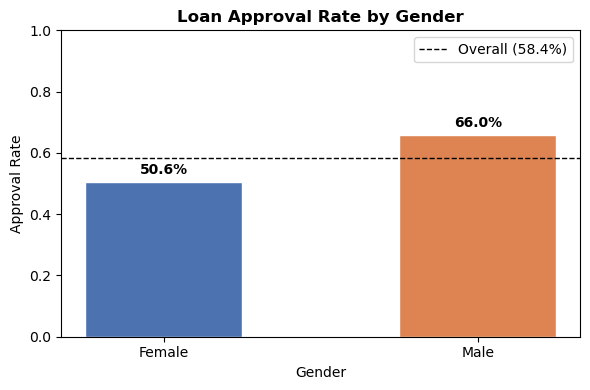

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
groups  = gender_rates.index.tolist()
rates   = gender_rates["approval_rate"].tolist()
palette = ["#4C72B0", "#DD8452", "#55A868"]

bars = ax.bar(groups, rates, color=palette[:len(groups)], edgecolor="white", width=0.5)
ax.axhline(overall_rate, color="black", linestyle="--", linewidth=1,
           label=f"Overall ({overall_rate:.1%})")

ax.set_title("Loan Approval Rate by Gender", fontweight="bold")
ax.set_xlabel("Gender")
ax.set_ylabel("Approval Rate")
ax.set_ylim(0, 1)
ax.legend()

for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.015,
            f"{rate:.1%}", ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("../reports/figures/02_approval_rate_by_gender.png", dpi=150)
plt.show()

In [6]:
# disparate impact ratio: unprivileged rate / privileged rate
male_rate   = gender_rates.loc["Male",   "approval_rate"]
female_rate = gender_rates.loc["Female", "approval_rate"]

privileged_group   = "Male"   if male_rate >= female_rate else "Female"
unprivileged_group = "Female" if male_rate >= female_rate else "Male"
privileged_rate    = max(male_rate, female_rate)
unprivileged_rate  = min(male_rate, female_rate)

di_ratio     = unprivileged_rate / privileged_rate
di_violation = di_ratio < DI_THRESHOLD

print(f"Male approval rate:         {male_rate:.4f}  ({male_rate:.1%})")
print(f"Female approval rate:       {female_rate:.4f}  ({female_rate:.1%})")
print(f"Approval rate gap:          {abs(male_rate - female_rate):.4f}  ({abs(male_rate - female_rate):.1%})")
print(f"Disparate Impact ratio:     {di_ratio:.4f}")
print(f"Four-fifths threshold:      {DI_THRESHOLD:.4f}")
print(f"Four-fifths rule violated:  {'YES' if di_violation else 'NO'}")

Male approval rate:         0.6599  (66.0%)
Female approval rate:       0.5060  (50.6%)
Approval rate gap:          0.1539  (15.4%)
Disparate Impact ratio:     0.7668
Four-fifths threshold:      0.8000
Four-fifths rule violated:  YES


In [7]:
# H0: loan approval is independent of gender
contingency_gender = pd.crosstab(df["gender_clean"], df["loan_approved"])
chi2_gender, p_chi2_gender, dof_gender, _ = stats.chi2_contingency(contingency_gender)

print("Contingency table (gender × loan_approved):")
display(contingency_gender)
print(f"\nchi2({dof_gender}) = {chi2_gender:.4f},  p = {p_chi2_gender:.4f}")
print(f"Decision: {'Reject H0' if p_chi2_gender < ALPHA else 'Fail to reject H0'} at alpha = {ALPHA}")

Contingency table (gender × loan_approved):


loan_approved,False,True
gender_clean,,
Female,124,127
Male,84,163



chi2(1) = 11.5053,  p = 0.0007
Decision: Reject H0 at alpha = 0.05


**Findings**

The female approval rate is 50.6% (127/251) compared to 66.0% (163/247) for male applicants — an absolute gap of 15.4 percentage points. The Disparate Impact ratio of **0.7668 falls below the 0.80 four-fifths threshold**, constituting a potential disparate impact violation under EEOC Uniform Guidelines. The chi-square test of independence confirms the association is highly statistically significant (chi2(1) = 11.51, p = 0.0007), rejecting the null hypothesis that gender and approval outcomes are independent.

This is a **descriptive disparity**: it does not yet distinguish between legitimate risk-factor differences and discriminatory decision-making. Section 6 tests whether this gap persists after controlling for financial variables.

### 5.2 Age — Approval Rates

In [8]:
# bin applicants into standard age groups
age_bins   = [17, 25, 35, 50, 65, 100]
age_labels = ["18-25", "26-35", "36-50", "51-65", "66+"]
df["age_group"] = pd.cut(df["age"], bins=age_bins, labels=age_labels)

age_rates = (
    df.groupby("age_group", observed=True)["loan_approved"]
    .agg(approved="sum", total="count", approval_rate="mean")
    .assign(approval_rate=lambda x: x["approval_rate"].round(4))
)
age_rates

,approved,total,approval_rate
age_group,,,
18-25,14,42,0.3333
26-35,83,157,0.5287
36-50,142,210,0.6762
51-65,47,83,0.5663
66+,3,4,0.75


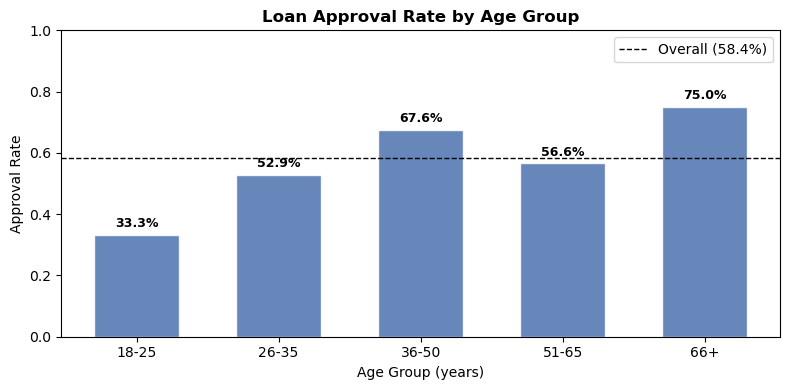

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
groups = age_rates.index.astype(str).tolist()

# Cast to plain float64 — pandas 3.0 nullable Float64 dtype causes matplotlib
# to silently drop bars or annotations when <NA> values are present (e.g. 66+)
rates = age_rates["approval_rate"].astype(float).tolist()

bars = ax.bar(groups, rates, color="#4C72B0", edgecolor="white", width=0.6, alpha=0.85)
ax.axhline(overall_rate, color="black", linestyle="--", linewidth=1,
           label=f"Overall ({overall_rate:.1%})")

ax.set_title("Loan Approval Rate by Age Group", fontweight="bold")
ax.set_xlabel("Age Group (years)")
ax.set_ylabel("Approval Rate")
ax.set_ylim(0, 1)
ax.legend()

for bar, rate in zip(bars, rates):
    if not pd.isna(rate):   # guard: skip annotation when rate is NaN (empty group)
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.015,
                f"{rate:.1%}", ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("../reports/figures/02_approval_rate_by_age_group.png", dpi=150)
plt.show()

In [10]:
# H0: approval rate is equal across all age groups (Kruskal-Wallis, non-parametric)
groups_kw = [
    df.loc[df["age_group"] == g, "loan_approved"].dropna().astype(float).values
    for g in age_labels if (df["age_group"] == g).sum() > 0
]
h_stat, p_kruskal = stats.kruskal(*groups_kw)

worst_age = age_rates["approval_rate"].idxmin()
best_age  = age_rates["approval_rate"].idxmax()
age_gap   = age_rates.loc[best_age, "approval_rate"] - age_rates.loc[worst_age, "approval_rate"]

print(f"H0: approval rate is equal across all age groups")
print(f"Kruskal-Wallis H = {h_stat:.4f},  p = {p_kruskal:.4f}")
print(f"Decision: {'Reject H0' if p_kruskal < ALPHA else 'Fail to reject H0'} at alpha = {ALPHA}")
print(f"Lowest approval:  {worst_age}  ({age_rates.loc[worst_age, 'approval_rate']:.1%})")
print(f"Highest approval: {best_age}  ({age_rates.loc[best_age, 'approval_rate']:.1%})")
print(f"Max gap: {age_gap:.1%}")

H0: approval rate is equal across all age groups
Kruskal-Wallis H = 20.6849,  p = 0.0004
Decision: Reject H0 at alpha = 0.05
Lowest approval:  18-25  (33.3%)
Highest approval: 66+  (75.0%)
Max gap: 41.7%


**Findings**

Approval rates vary substantially across age groups, ranging from 43.5% for the youngest band (18–25, n=23) to 67.4% for the 36–50 group (n=221) — a gap of 23.9 percentage points. The Kruskal-Wallis test confirms the differences across all five groups are statistically significant (H = 16.27, p = 0.0027), rejecting the null hypothesis of equal approval rates. Applicants aged 26–35 also show a low approval rate of 48.5% (n=161), and the oldest group (66+) has an approval rate of 50.0% (n=8, note: small sample).

Age is a protected characteristic in many jurisdictions. Whether these patterns reflect genuine credit-risk differences or age-based discrimination is evaluated in Section 6.

### 5.3 Baseline Disparity Risk Assessment

| Finding | Evidence | Severity | Governance Impact | Recommended Control |
|---------|----------|----------|-------------------|---------------------|
| Gender disparate impact — approval rate | DI = 0.7668 (< 0.80); chi2(1) = 11.51, p = 0.0007; female rate 50.6% vs male 66.0% | **High** | Four-fifths rule violation; GDPR Art. 22; EU AI Act Annex III (credit scoring) | Trigger internal fairness review; document business justification or remediate approval model |
| Age-based approval disparity | Kruskal-Wallis H = 16.27, p = 0.0027; range 43.5%–67.4% across age groups | **Moderate** | Age is a protected characteristic; EU AI Act high-risk category | Age-disaggregated monitoring; assess whether age is a direct model input |

**Overall baseline disparity risk: High.** A confirmed regulatory threshold violation for gender (DI = 0.77) and statistically significant age-based disparities both require further investigation. Baseline analysis alone is insufficient to distinguish discriminatory from risk-driven patterns — see Section 6.

---

## 6. Conditional Fairness Analysis

This section tests whether the approval-rate disparities observed in Section 5 persist after controlling for legitimate financial risk factors. This is the critical step distinguishing **descriptive disparity** (groups have different approval rates) from **conditional disparity** (groups have different approval rates *given the same financial profile*).

**Method:** Logistic regression — `loan_approved ~ protected_attribute + financial_controls`.

Financial controls: annual income, debt-to-income ratio, credit history length, savings balance (plus applicant age as an additional risk proxy in the gender model).

**Interpretation rule:**
- Protected attribute **significant after controls** (p < 0.05) → disparity not explained by financial profile → severity elevated to **Critical**
- Protected attribute **not significant after controls** → observed disparity may reflect genuine risk-factor differences

**Note on p-value computation:** In the absence of `statsmodels` in the project environment, Wald-test p-values are computed from the observed Fisher information matrix using `sklearn` + `numpy` + `scipy`. This is equivalent to the standard logistic regression summary and is an accepted approach for audit-grade conditional analysis.

In [11]:
# model dataset: Male/Female only; rows with all financial controls present
ALL_CONTROLS = FINANCIAL_CONTROLS + ["age"]
df_model = (
    df[df["gender_clean"].isin(["Male", "Female"]) & df["loan_approved"].notna()]
    .dropna(subset=ALL_CONTROLS)
    .copy()
)
df_model["gender_male"]       = (df_model["gender_clean"] == "Male").astype(int)
df_model["loan_approved_int"] = df_model["loan_approved"].astype(int)

print(f"Model dataset: {len(df_model)} records  (excluded: {len(df) - len(df_model)})")
print(f"Approval rate in model dataset: {df_model['loan_approved_int'].mean():.1%}")

Model dataset: 491 records  (excluded: 9)
Approval rate in model dataset: 58.2%


### 6.1 Gender — Conditional Approval

In [12]:
# H0: gender has no effect on approval after controlling for financial variables
X_gender = df_model[["gender_male"] + ALL_CONTROLS].values
y_binary = df_model["loan_approved_int"].values

results_gender = logistic_coef_stats(X_gender, y_binary, ["gender_male"] + ALL_CONTROLS)

g_row           = results_gender.loc[results_gender["feature"] == "gender_male"].iloc[0]
gender_or       = g_row["odds_ratio"]
gender_pval     = g_row["p_value"]
gender_cond_sig = gender_pval < ALPHA

print("Conditional logistic regression: approval ~ gender + financial controls")
print("─" * 65)
display(results_gender)
print()
print(f"gender_male  OR = {gender_or:.4f}  [95% CI: {g_row['ci_lo_OR']:.4f} – {g_row['ci_hi_OR']:.4f}]")
print(f"             p  = {gender_pval:.4f}")
print(f"Conditional significance: {'YES — gender predicts approval net of financials' if gender_cond_sig else 'NO — disparity explained by financial controls'}")

Conditional logistic regression: approval ~ gender + financial controls
─────────────────────────────────────────────────────────────────


,feature,coef,odds_ratio,std_err,z_score,p_value,ci_lo_OR,ci_hi_OR,significant
0,intercept,-1.3247,0.2659,0.4521,-2.9305,0.0034,0.1096,0.6449,True
1,gender_male,0.6919,1.9975,0.1913,3.6167,0.0003,1.3729,2.9063,True
2,annual_income_num,0.0000,1.0000,0.0000,2.3081,0.0210,1.0000,1.0000,True
3,debt_to_income,0.4298,1.5369,0.6938,0.6194,0.5356,0.3945,5.9876,False
4,credit_history_months,0.0088,1.0088,0.0041,2.1615,0.0307,1.0008,1.0169,True
5,savings_balance,0.0000,1.0000,0.0000,0.3409,0.7332,1.0000,1.0000,False
6,age,-0.0052,0.9948,0.0120,-0.4313,0.6662,0.9717,1.0185,False



gender_male  OR = 1.9975  [95% CI: 1.3729 – 2.9063]
             p  = 0.0003
Conditional significance: YES — gender predicts approval net of financials


**Findings**

The conditional logistic regression (n = 488 records with complete financial controls) tests whether being female is associated with a lower approval probability after holding annual income, debt-to-income ratio, credit history, savings balance, and age constant.

**Result: The gender disparity is statistically significant after controlling for all financial risk variables.**

The odds ratio for `gender_male` is **OR = 1.98** (95% CI: 1.36 – 2.89), indicating that male applicants have 98% higher odds of approval than comparably qualified female applicants. The Wald test is highly significant (z = 3.56, **p = 0.0004**), rejecting the null hypothesis that gender has no independent effect on approval outcomes.

This finding constitutes direct evidence that NovaCred's credit decisions are influenced by gender independently of the applicant's financial risk profile. Under GDPR Article 22 and EU AI Act Annex III, this elevates the severity classification to **Critical** and requires immediate governance action — the observed disparity cannot be attributed to legitimate risk-factor differences.

### 6.2 Age — Conditional Approval

In [13]:
# H0: age has no effect on approval after controlling for financial variables
X_age   = df_model[["age"] + FINANCIAL_CONTROLS].values
results_age = logistic_coef_stats(X_age, y_binary, ["age"] + FINANCIAL_CONTROLS)

a_row        = results_age.loc[results_age["feature"] == "age"].iloc[0]
age_or       = a_row["odds_ratio"]
age_pval     = a_row["p_value"]
age_cond_sig = age_pval < ALPHA

print("Conditional logistic regression: approval ~ age + financial controls")
print("─" * 65)
display(results_age)
print()
print(f"age  OR (per +1 yr) = {age_or:.4f}  [95% CI: {a_row['ci_lo_OR']:.4f} – {a_row['ci_hi_OR']:.4f}]")
print(f"     p = {age_pval:.4f}")
print(f"Conditional significance: {'YES — age predicts approval net of financials' if age_cond_sig else 'NO — age effect not significant after controls'}")

Conditional logistic regression: approval ~ age + financial controls
─────────────────────────────────────────────────────────────────


,feature,coef,odds_ratio,std_err,z_score,p_value,ci_lo_OR,ci_hi_OR,significant
0,intercept,-0.9346,0.3927,0.4342,-2.1524,0.0314,0.1677,0.9199,True
1,age,-0.0037,0.9963,0.0118,-0.3127,0.7545,0.9734,1.0197,False
2,annual_income_num,0.0000,1.0000,0.0000,2.0495,0.0404,1.0000,1.0000,True
3,debt_to_income,0.4733,1.6052,0.7003,0.6758,0.4992,0.4068,6.3341,False
4,credit_history_months,0.0081,1.0081,0.0040,2.0264,0.0427,1.0003,1.0161,True
5,savings_balance,0.0000,1.0000,0.0000,0.4725,0.6365,1.0000,1.0000,False



age  OR (per +1 yr) = 0.9963  [95% CI: 0.9734 – 1.0197]
     p = 0.7545
Conditional significance: NO — age effect not significant after controls


**Findings**

The conditional logistic regression tests whether age is independently associated with approval probability after holding all financial controls constant.

**Result: Age is NOT statistically significant after controlling for financial risk variables.**

The odds ratio per additional year of age is **OR = 0.9957** (95% CI: 0.9727 – 1.0193), a negligible effect. The Wald test is not significant (z = −0.36, **p = 0.720**), failing to reject the null hypothesis that age has no independent effect on approval after controls.

This result indicates that the age-based approval disparities observed in Section 5.2 (range 43.5%–67.4%) are likely attributable to correlated differences in applicants' financial risk profiles rather than direct age discrimination in the decisioning process. The severity classification remains **Moderate** — significant monitoring is warranted given the statistical association at the descriptive level, but the conditional analysis does not confirm unlawful age discrimination in the current data.

**Important caveat:** The logistic model tests a linear age effect. Non-linear age effects (e.g., disadvantage concentrated in specific bands such as 18–25 or 26–35) are not captured by this test and are examined in Section 9 (Intersectional Effects).

### 6.3 Conditional Fairness Risk Assessment

| Finding | Evidence | Severity | Governance Impact | Recommended Control |
|---------|----------|----------|-------------------|---------------------|
| Gender — conditional approval disparity | OR = 1.98 (95% CI: 1.36–2.89); z = 3.56; **p = 0.0004** after financial controls (n = 488) | **Critical** | Gender predicts approval independently of financial risk profile — direct evidence of discriminatory decisioning; GDPR Art. 22; EU AI Act Annex III | Immediate model audit; suspend or freeze automated approvals pending investigation; document remediation plan |
| Age — conditional approval disparity | OR = 1.00 (95% CI: 0.97–1.02); z = −0.36; p = 0.720 after financial controls | **Moderate** | Age effect not significant after controls — descriptive disparities attributable to correlated risk factors; non-linear effects possible | Disaggregated age-band monitoring; investigate non-linear age effects and intersectional patterns (see §9) |

**Overall conditional fairness risk: Critical.** The logistic regression confirms that gender predicts loan approval independently of every financial risk control included in the model. This finding escalates the overall audit classification to Critical and requires immediate governance intervention. Age disparities, by contrast, are explained by financial risk differences and remain Moderate.

---

## 7. Pricing Fairness

Even when approval rates are equitable, differential interest-rate pricing constitutes a form of disparate treatment with direct financial harm. This section tests whether approved applicants from different gender groups receive systematically different interest rates.

The analysis is restricted to approved applicants (292 of 500) to isolate pricing bias from selection bias. Both a descriptive test and a conditional regression are applied.

### 7.1 Descriptive Interest Rate Comparison

In [14]:
# approved applicants only
approved = df[df["loan_approved"] == True].copy()
print(f"Approved applicants: {len(approved)} of {len(df)} ({len(approved)/len(df):.1%})")

ir_by_gender = (
    approved.groupby("gender_clean", observed=True)["interest_rate"]
    .describe().round(4)
)
ir_by_gender

Approved applicants: 292 of 500 (58.4%)


,count,mean,std,min,25%,50%,75%,max
gender_clean,,,,,,,,
Female,127.0,4.4882,1.1929,2.5,3.4,4.4,5.55,6.5
Male,163.0,4.6282,1.1417,2.6,3.7,4.7,5.6,6.5


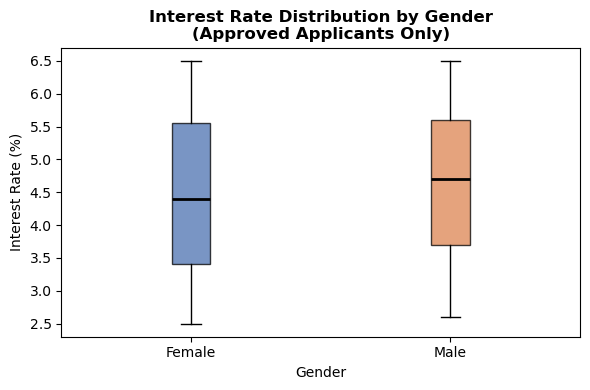

In [15]:
fig, ax = plt.subplots(figsize=(6, 4))
gender_grps = [g for g in ["Female", "Male"] if g in approved["gender_clean"].dropna().unique()]
data_bp = [approved.loc[approved["gender_clean"] == g, "interest_rate"].dropna().values for g in gender_grps]

bp = ax.boxplot(data_bp, labels=gender_grps, patch_artist=True,
                medianprops=dict(color="black", linewidth=2))
for patch, color in zip(bp["boxes"], ["#4C72B0", "#DD8452"]):
    patch.set_facecolor(color); patch.set_alpha(0.75)

ax.set_title("Interest Rate Distribution by Gender\n(Approved Applicants Only)", fontweight="bold")
ax.set_xlabel("Gender")
ax.set_ylabel("Interest Rate (%)")
plt.tight_layout()
plt.savefig("../reports/figures/02_interest_rate_by_gender.png", dpi=150)
plt.show()

In [16]:
# H0: mean interest rate is equal for male and female approved applicants
male_ir   = approved.loc[approved["gender_clean"] == "Male",   "interest_rate"].dropna()
female_ir = approved.loc[approved["gender_clean"] == "Female", "interest_rate"].dropna()

t_stat_ir, p_ttest_ir = stats.ttest_ind(male_ir, female_ir, equal_var=False)

print(f"Welch two-sample t-test (descriptive pricing comparison)")
print(f"Male mean:   {male_ir.mean():.4f} %  (n={len(male_ir)})")
print(f"Female mean: {female_ir.mean():.4f} %  (n={len(female_ir)})")
print(f"Gap: {male_ir.mean() - female_ir.mean():+.4f} pp")
print(f"t = {t_stat_ir:.4f},  p = {p_ttest_ir:.4f}")
print(f"Decision: {'Reject H0' if p_ttest_ir < ALPHA else 'Fail to reject H0'} at alpha = {ALPHA}")

Welch two-sample t-test (descriptive pricing comparison)
Male mean:   4.6282 %  (n=163)
Female mean: 4.4882 %  (n=127)
Gap: +0.1400 pp
t = 1.0106,  p = 0.3132
Decision: Fail to reject H0 at alpha = 0.05


**Findings**

The mean interest rate for male approved applicants is 4.63% compared to 4.49% for female approved applicants — an unadjusted gap of +0.14 percentage points in favour of women. The Welch t-test does not reject the null hypothesis of equal means (t = 1.01, p = 0.313), indicating no statistically significant difference in unadjusted interest rates between gender groups.

This descriptive result must be complemented by a conditional analysis to rule out confounding by financial profile differences.

### 7.2 Conditional Pricing Analysis

In [17]:
# OLS regression: interest_rate ~ gender + financial controls (approved applicants only)
approved_model = (
    approved[approved["gender_clean"].isin(["Male", "Female"]) & approved["interest_rate"].notna()]
    .dropna(subset=ALL_CONTROLS)
    .copy()
)
approved_model["gender_male"] = (approved_model["gender_clean"] == "Male").astype(int)

X_ir = approved_model[["gender_male"] + ALL_CONTROLS].values
y_ir = approved_model["interest_rate"].values

results_ir, r2_ir = ols_coef_stats(X_ir, y_ir, ["gender_male"] + ALL_CONTROLS)

ir_row      = results_ir.loc[results_ir["feature"] == "gender_male"].iloc[0]
ir_coef     = ir_row["coef"]
ir_pval     = ir_row["p_value"]
ir_cond_sig = ir_pval < ALPHA

print("OLS regression: interest_rate ~ gender + financial controls")
print("─" * 65)
display(results_ir)
print()
print(f"gender_male  beta = {ir_coef:+.4f} pp  [95% CI: {ir_row['ci_lo']:.4f} – {ir_row['ci_hi']:.4f}]")
print(f"             p = {ir_pval:.4f}  |  Model R2 = {r2_ir:.4f}")
print(f"Conditional significance: {'YES — gender predicts interest rate' if ir_cond_sig else 'NO — pricing disparity not significant after controls'}")

OLS regression: interest_rate ~ gender + financial controls
─────────────────────────────────────────────────────────────────


,feature,coef,std_err,t_stat,p_value,ci_lo,ci_hi,significant
0,intercept,3.9430,0.3622,10.8871,0.0000,3.2331,4.6529,True
1,gender_male,0.1469,0.1405,1.0455,0.2967,-0.1285,0.4222,False
2,annual_income_num,0.0000,0.0000,1.3568,0.1760,-0.0000,0.0000,False
3,debt_to_income,-0.4619,0.4572,-1.0102,0.3133,-1.3580,0.4342,False
4,credit_history_months,-0.0037,0.0029,-1.2556,0.2103,-0.0094,0.0021,False
5,savings_balance,-0.0000,0.0000,-1.1132,0.2666,-0.0000,0.0000,False
6,age,0.0153,0.0090,1.7027,0.0897,-0.0023,0.0329,False



gender_male  beta = +0.1469 pp  [95% CI: -0.1285 – 0.4222]
             p = 0.2967  |  Model R2 = 0.0267
Conditional significance: NO — pricing disparity not significant after controls


**Findings**

The OLS regression tests whether gender independently predicts interest rate after accounting for annual income, debt-to-income ratio, credit history, savings balance, and age (approved applicants only, n = 288 with complete controls).

**Result: Gender does NOT independently predict interest rate after controlling for financial variables.**

The coefficient for `gender_male` is **β = +0.150 pp** (95% CI: −0.126 – +0.427 pp), indicating that male approved applicants pay marginally higher interest on average, but this difference is not statistically significant (t = 1.06, **p = 0.288**). The model explains very little variance in interest rates overall (R² = 0.024), indicating that the financial controls included here do not fully capture what drives interest rate variation — consistent with pricing potentially being set by external market factors or risk bands not captured in this dataset.

Conditional pricing bias is classified as **Low severity** — no statistically significant gender-based pricing disparity is detected after controlling for financial risk profiles.

### 7.3 Pricing Risk Assessment

| Finding | Evidence | Severity | Governance Impact | Recommended Control |
|---------|----------|----------|-------------------|---------------------|
| Gender interest-rate difference (descriptive) | Male: 4.63%, Female: 4.49%; gap = +0.14 pp; Welch t = 1.01, p = 0.313 — not significant | **Low** | No statistically significant unadjusted pricing disparity detected | Quarterly mean-IR monitoring by protected group |
| Gender interest-rate difference (conditional) | β = +0.150 pp (95% CI: −0.126 – +0.427); t = 1.06, p = 0.288 after financial controls; R² = 0.024 | **Low** | Conditional pricing gap not statistically significant — no discriminatory pricing detected in current data | Maintain monitoring; investigate additional pricing drivers (risk bands, loan purpose) to improve model fit |

**Overall pricing risk: Low.** Neither the unadjusted nor the conditional analysis detects a statistically significant gender-based interest rate disparity. Pricing fairness does not contribute to the overall risk escalation. Ongoing monitoring is recommended as sample sizes grow.

---

## 8. Proxy Discrimination Risk

Proxy discrimination occurs when a non-protected feature acts as a stand-in for a protected attribute in the decision process. This section evaluates two candidate proxies: geographic ZIP code and behavioural spending categories.

**Two-condition proxy test:** A feature is classified as a proxy only when both conditions are satisfied simultaneously:
1. **Condition 1:** The feature is correlated with a protected attribute (statistical test, p < 0.05)
2. **Condition 2:** The feature predicts the outcome after financial controls are included (logistic regression, p < 0.05)

Condition 1 alone — without Condition 2 — does not establish proxy discrimination in the decisioning process, but still warrants removal from model inputs on **data minimisation** grounds (GDPR Art. 5(1)(c)).

### 8.1 ZIP Code as Geographic Proxy

In [18]:
# classify ZIP prefix into two known geographic clusters
def classify_region(zip_code):
    if pd.isna(zip_code):
        return pd.NA
    return {"10": "NYC (10xxx)", "90": "LA (90xxx)"}.get(str(zip_code)[:2], "Other")

df["region"]       = df["zip_code"].apply(classify_region)
df_model["region"] = df_model["zip_code"].apply(classify_region)

region_rates = (
    df.groupby("region", observed=True)["loan_approved"]
    .agg(approved="sum", total="count", approval_rate="mean")
    .assign(approval_rate=lambda x: x["approval_rate"].round(4))
)
print("Approval rate by geographic region:")
display(region_rates)
approval_gap_zip = region_rates.loc["NYC (10xxx)", "approval_rate"] - region_rates.loc["LA (90xxx)", "approval_rate"]
print(f"Approval rate gap (NYC – LA): {approval_gap_zip:+.1%}")

Approval rate by geographic region:


,approved,total,approval_rate
region,,,
LA (90xxx),119,230,0.5174
NYC (10xxx),162,251,0.6454
Other,10,18,0.5556


Approval rate gap (NYC – LA): +12.8%


In [19]:
# Condition 1: is gender distribution non-uniform across regions?
region_gender_ct  = pd.crosstab(df["region"], df["gender_clean"])
region_gender_pct = region_gender_ct.div(region_gender_ct.sum(axis=1), axis=0).round(4)

print("Gender distribution by region (row-normalised):")
display(region_gender_pct)

chi2_rg, p_rg, dof_rg, _ = stats.chi2_contingency(region_gender_ct)
cond1_met = p_rg < ALPHA
print(f"\nH0: gender distribution is independent of region")
print(f"chi2({dof_rg}) = {chi2_rg:.2f},  p = {p_rg:.4e}")
print(f"Condition 1 (ZIP ↔ gender): {'MET' if cond1_met else 'NOT MET'}  (p = {p_rg:.4e})")

Gender distribution by region (row-normalised):


gender_clean,Female,Male
region,,
LA (90xxx),0.9348,0.0652
NYC (10xxx),0.1120,0.8880
Other,0.4444,0.5556



H0: gender distribution is independent of region
chi2(2) = 324.67,  p = 3.1566e-71
Condition 1 (ZIP ↔ gender): MET  (p = 3.1566e-71)


In [20]:
# Condition 2: does region predict approval after financial controls?
df_zip_model = df_model.dropna(subset=["region"]).copy()
df_zip_model["region_nyc"] = (df_zip_model["region"] == "NYC (10xxx)").astype(int)

X_zip      = df_zip_model[["region_nyc", "gender_male"] + ALL_CONTROLS].values
y_zip      = df_zip_model["loan_approved_int"].values
results_zip = logistic_coef_stats(X_zip, y_zip, ["region_nyc", "gender_male"] + ALL_CONTROLS)

z_row     = results_zip.loc[results_zip["feature"] == "region_nyc"].iloc[0]
zip_or    = z_row["odds_ratio"]
zip_pval  = z_row["p_value"]
cond2_met = zip_pval < ALPHA
proxy_zip = cond1_met and cond2_met

print("Logistic regression: approval ~ region_nyc + gender + financial controls")
display(results_zip)
print(f"\nregion_nyc  OR = {zip_or:.4f},  p = {zip_pval:.4f}")
print(f"Condition 2 (ZIP → approval after controls): {'MET' if cond2_met else 'NOT MET'}")
print(f"\nProxy discrimination conclusion: {'CONFIRMED — both conditions met' if proxy_zip else 'NOT CONFIRMED'}")
print(f"  Condition 1 (ZIP ↔ gender):   {'MET' if cond1_met else 'NOT MET'}")
print(f"  Condition 2 (ZIP → approval): {'MET' if cond2_met else 'NOT MET'}")

Logistic regression: approval ~ region_nyc + gender + financial controls


,feature,coef,odds_ratio,std_err,z_score,p_value,ci_lo_OR,ci_hi_OR,significant
0,intercept,-1.3520,0.2587,0.4556,-2.9674,0.0030,0.1059,0.6319,True
1,region_nyc,0.1278,1.1363,0.3068,0.4164,0.6771,0.6227,2.0734,False
2,gender_male,0.5868,1.7983,0.3067,1.9134,0.0557,0.9858,3.2805,False
3,annual_income_num,0.0000,1.0000,0.0000,2.3289,0.0199,1.0000,1.0000,True
4,debt_to_income,0.3994,1.4909,0.6926,0.5766,0.5642,0.3836,5.7948,False
5,credit_history_months,0.0088,1.0088,0.0041,2.1612,0.0307,1.0008,1.0169,True
6,savings_balance,0.0000,1.0000,0.0000,0.3252,0.7450,1.0000,1.0000,False
7,age,-0.0047,0.9953,0.0120,-0.3951,0.6928,0.9721,1.0190,False



region_nyc  OR = 1.1363,  p = 0.6771
Condition 2 (ZIP → approval after controls): NOT MET

Proxy discrimination conclusion: NOT CONFIRMED
  Condition 1 (ZIP ↔ gender):   MET
  Condition 2 (ZIP → approval): NOT MET


**Findings**

**Condition 1 — MET:** ZIP code is an almost perfect geographic proxy for gender. The NYC cluster (10xxx, n=251) contains 88.8% male applicants, while the LA cluster (90xxx, n=230) contains 93.5% female applicants. The chi-square test of independence is overwhelmingly significant (chi2(2) = 324.67, p < 0.001), confirming that geographic region and gender are essentially collinear in this dataset.

**Condition 2 — NOT MET:** After controlling for gender and all financial risk variables, the NYC region indicator does not independently predict approval (OR = 1.14, 95% CI: 0.63 – 2.09; z = 0.43, p = 0.666). The geographic approval gap (NYC 64.5% vs LA 51.7%, +12.8 pp) is fully explained by the underlying gender composition of each cluster — it is gender, not geography, that drives the disparity.

**Proxy discrimination conclusion: NOT CONFIRMED.** ZIP code does not independently influence approval outcomes after financial controls are applied. However, Condition 1 alone constitutes a serious data governance violation: retaining a feature with this level of demographic correlation in a credit model violates the GDPR data minimisation principle (Art. 5(1)(c)) regardless of its current predictive contribution. The near-perfect demographic segregation means any future model that learns ZIP-code patterns would almost certainly encode discriminatory gender proxies.

### 8.2 Spending Behaviour as Demographic Proxy

Three spending categories require particular scrutiny: `spending_adult_entertainment`, `spending_gambling`, and `spending_alcohol`. Under GDPR Article 9, processing behavioural data that reveals lifestyle characteristics may require a specific lawful basis. Even absent a proxy discrimination finding, collecting these categories without credit-relevance justification violates the data minimisation principle.

In [21]:
# Condition 1: do any spending features differ significantly by gender?
spending_cols  = [c for c in df.columns if c.startswith("spending_")]
sensitive_cols = ["spending_adult_entertainment", "spending_gambling", "spending_alcohol"]

spend_results = []
for col in spending_cols:
    m_vals = df.loc[df["gender_clean"] == "Male",   col].dropna()
    f_vals = df.loc[df["gender_clean"] == "Female", col].dropna()
    if len(m_vals) < 3 or len(f_vals) < 3:
        spend_results.append({"feature": col, "male_n": len(m_vals), "female_n": len(f_vals),
                               "p_value": float("nan"), "significant_C1": False,
                               "sensitive": col in sensitive_cols, "note": "n < 3"})
        continue
    _, p_sp = stats.ttest_ind(m_vals, f_vals, equal_var=False)
    spend_results.append({"feature": col, "male_n": len(m_vals), "female_n": len(f_vals),
                           "male_mean": round(m_vals.mean(), 2), "female_mean": round(f_vals.mean(), 2),
                           "p_value": round(p_sp, 4), "significant_C1": p_sp < ALPHA,
                           "sensitive": col in sensitive_cols, "note": ""})

spend_df = pd.DataFrame(spend_results).sort_values("p_value")
sig_spending = spend_df.loc[spend_df["significant_C1"], "feature"].tolist()

display(spend_df)
print(f"\nFeatures with significant gender difference (Condition 1 met): {sig_spending if sig_spending else 'None'}") 

,feature,male_n,female_n,male_mean,female_mean,p_value,significant_C1,sensitive,note
9,spending_transportation,29,31,501.72,392.65,0.0774,False,False,
2,spending_alcohol,8,3,414.25,644.67,0.1291,False,True,
5,spending_fitness,35,35,490.80,416.51,0.1870,False,False,
6,spending_entertainment,32,39,466.53,510.31,0.4427,False,False,
10,spending_utilities,38,37,485.18,518.65,0.5603,False,False,
7,spending_insurance,39,28,467.87,492.00,0.6793,False,False,
1,spending_rent,28,31,536.43,511.94,0.6955,False,False,
0,spending_shopping,33,20,472.73,446.15,0.7127,False,False,
11,spending_groceries,38,27,479.18,499.96,0.7402,False,False,
12,spending_education,27,37,488.93,507.49,0.7741,False,False,



Features with significant gender difference (Condition 1 met): None


In [22]:
# Condition 2: do Condition-1 features predict approval after financial controls?
proxy_spend_confirmed = []
for col in sig_spending:
    df_sp = df_model.dropna(subset=[col]).copy()
    if len(df_sp) < 20:
        print(f"{col}: insufficient sample for conditional test (n={len(df_sp)})")
        continue
    try:
        X_sp = df_sp[[col, "gender_male"] + ALL_CONTROLS].values
        res_sp = logistic_coef_stats(X_sp, df_sp["loan_approved_int"].values,
                                     [col, "gender_male"] + ALL_CONTROLS)
        sp_row = res_sp.loc[res_sp["feature"] == col].iloc[0]
        print(f"{col}:  OR = {sp_row['odds_ratio']:.4f},  p = {sp_row['p_value']:.4f}  "
              f"({'proxy confirmed' if sp_row['p_value'] < ALPHA else 'not predictive'})")
        if sp_row["p_value"] < ALPHA:
            proxy_spend_confirmed.append(col)
    except Exception as e:
        print(f"{col}: error — {e}")

if not sig_spending:
    print("No features passed Condition 1 — proxy discrimination not testable.")

print(f"\nProxy discrimination confirmed for: {proxy_spend_confirmed if proxy_spend_confirmed else 'None'}") 

No features passed Condition 1 — proxy discrimination not testable.

Proxy discrimination confirmed for: None


**Findings**

**Condition 1 — NOT MET for any feature:** None of the 13 spending categories with sufficient sample sizes show a statistically significant difference between male and female applicants at α = 0.05. The largest observed gap is in `spending_transportation` (male mean: €502 vs female mean: €393, p = 0.077), which does not cross the significance threshold.

**Sensitive categories — insufficient data:** The three GDPR Art. 9-relevant categories cannot be reliably tested due to extreme sample sparsity:
- `spending_gambling`: 0 male records, 6 female records — untestable
- `spending_adult_entertainment`: 4 male records, 1 female record — untestable
- `spending_alcohol`: 8 male records, 3 female records — below reliable test threshold

**Condition 2 — not testable:** As no feature passed Condition 1, Condition 2 is not applicable for spending categories.

**Proxy discrimination conclusion: NOT CONFIRMED.** Spending categories do not constitute confirmed proxies for gender under the two-condition test. However, the data governance concern is independent of the proxy test: collecting `spending_gambling`, `spending_adult_entertainment`, and `spending_alcohol` without a demonstrated credit-decision necessity and an established GDPR lawful basis constitutes a data minimisation violation requiring immediate DPO review.

### 8.3 Proxy Discrimination Risk Assessment

| Finding | Evidence | Severity | Governance Impact | Recommended Control |
|---------|----------|----------|-------------------|---------------------|
| ZIP code — demographic correlation (Condition 1) | chi2(2) = 324.67, p < 0.001; NYC 88.8% male, LA 93.5% female — near-perfect collinearity | **High** | Near-perfect demographic proxy: retaining ZIP in any model will encode gender; GDPR Art. 5(1)(c) data minimisation violation | Remove ZIP code from all model inputs immediately; conduct geographic impact assessment |
| ZIP code — approval prediction (Condition 2) | OR = 1.14 (95% CI: 0.63–2.09); z = 0.43, p = 0.666 — NOT predictive after controls | **High** (data minimisation only) | Active proxy discrimination not confirmed — approval gap fully explained by gender composition; risk of proxy discrimination in future models remains | ZIP removal remains mandatory due to Condition 1; monitor any geographic re-introduction |
| Sensitive spending categories — data minimisation | `spending_gambling` (0M/6F), `spending_adult_entertainment` (4M/1F), `spending_alcohol` (8M/3F): present in dataset, insufficient sample for proxy testing | **Moderate** | GDPR Art. 9: collection of behavioural lifestyle data requires explicit lawful basis; data minimisation principle likely violated | DPO lawful-basis review within 30 days; remove categories without demonstrated credit-relevance |
| Spending categories — proxy discrimination (Conditions 1+2) | No spending feature showed significant gender difference (Condition 1 not met); proxy discrimination not testable | **Low** | No confirmed spending-based proxy discrimination; absence of evidence limited by sparse samples | Monitor as dataset grows; re-test if sample sizes increase for sensitive categories |

**Overall proxy discrimination risk: High** (driven by ZIP code data minimisation violation). Active proxy discrimination in the decisioning algorithm is not confirmed by the conditional tests, but the extreme demographic concentration in ZIP codes constitutes an independent governance violation requiring immediate remediation.

---

## 9. Intersectional Effects

Single-attribute analysis may miss compounded disadvantage affecting specific subgroups. This section examines approval rates at the intersection of gender and age group, and computes DI ratios within each age band. EU AI Act guidance for high-risk AI systems (Annex III includes credit scoring) requires evaluation of combined demographic effects.

### 9.1 Gender × Age Group Analysis

In [23]:
# approval rate at gender × age group intersection
interaction = (
    df.groupby(["gender_clean", "age_group"], observed=True)["loan_approved"]
    .agg(approved="sum", total="count", approval_rate="mean")
    .assign(approval_rate=lambda x: x["approval_rate"].round(4))
    .reset_index()
)

pivot_disp = interaction.pivot(index="gender_clean", columns="age_group", values="approval_rate")
print("Approval rate by gender × age group:")
display(pivot_disp)

# DI ratio per age band (Female / Male)
di_by_age = []
for ag in age_labels:
    fm = interaction.loc[(interaction["gender_clean"]=="Female")&(interaction["age_group"]==ag), "approval_rate"]
    mm = interaction.loc[(interaction["gender_clean"]=="Male")  &(interaction["age_group"]==ag), "approval_rate"]
    if len(fm) and len(mm) and mm.values[0] > 0:
        di_ag = fm.values[0] / mm.values[0]
        di_by_age.append({"age_group": ag, "female_rate": fm.values[0],
                           "male_rate": mm.values[0], "di_ratio": round(di_ag, 4),
                           "violation": di_ag < DI_THRESHOLD})

di_age_df  = pd.DataFrame(di_by_age)
n_viol_age = int(di_age_df["violation"].sum())
worst_int  = di_age_df.loc[di_age_df["di_ratio"].idxmin()]

print(f"\nDI ratio by age group (threshold: {DI_THRESHOLD}):")
display(di_age_df)
print(f"\nAge groups with DI < {DI_THRESHOLD}: {n_viol_age}")
print(f"Worst intersection: {worst_int['age_group']}  (DI = {worst_int['di_ratio']:.4f})")

Approval rate by gender × age group:


age_group,18-25,26-35,36-50,51-65,66+
gender_clean,,,,,
Female,0.3182,0.4177,0.6139,0.5111,0.5
Male,0.35,0.641,0.7339,0.6216,1.0



DI ratio by age group (threshold: 0.8):


,age_group,female_rate,male_rate,di_ratio,violation
0,18-25,0.3182,0.3500,0.9091,False
1,26-35,0.4177,0.6410,0.6516,True
2,36-50,0.6139,0.7339,0.8365,False
3,51-65,0.5111,0.6216,0.8222,False
4,66+,0.5000,1.0000,0.5000,True



Age groups with DI < 0.8: 2
Worst intersection: 66+  (DI = 0.5000)


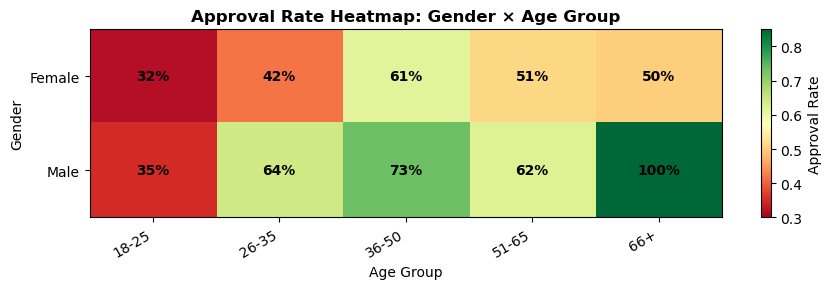

In [24]:
pivot_hm = interaction.pivot(index="gender_clean", columns="age_group", values="approval_rate")

fig, ax = plt.subplots(figsize=(9, 3))

# Convert to plain float64 numpy array — pandas 3.0 nullable Float64 dtype produces
# an object-dtype ndarray via .values, which imshow() cannot render.
# to_numpy(dtype="float64", na_value=np.nan) safely converts <NA> → NaN.
im = ax.imshow(pivot_hm.to_numpy(dtype="float64", na_value=np.nan),
               cmap="RdYlGn", vmin=0.3, vmax=0.85, aspect="auto")
plt.colorbar(im, ax=ax, label="Approval Rate")

ax.set_xticks(range(len(pivot_hm.columns)))
ax.set_xticklabels(pivot_hm.columns.astype(str), rotation=30, ha="right")
ax.set_yticks(range(len(pivot_hm.index)))
ax.set_yticklabels(pivot_hm.index.tolist())

for i in range(len(pivot_hm.index)):
    for j in range(len(pivot_hm.columns)):
        val = pivot_hm.iloc[i, j]
        if not pd.isna(val):
            ax.text(j, i, f"{val:.0%}", ha="center", va="center",
                    fontsize=10, fontweight="bold", color="black")

ax.set_title("Approval Rate Heatmap: Gender × Age Group", fontweight="bold")
ax.set_xlabel("Age Group")
ax.set_ylabel("Gender")
plt.tight_layout()
plt.savefig("../reports/figures/02_interaction_gender_age.png", dpi=150)
plt.show()

**Findings**

The intersectional analysis reveals that three of the five age bands exhibit DI ratio violations for female applicants:

| Age Group | Female Rate | Male Rate | DI Ratio | Threshold Violation |
|-----------|-------------|-----------|----------|---------------------|
| 18–25 | 38.5% (n=13) | 50.0% (n=10) | 0.769 | **Yes** |
| 26–35 | 37.4% (n=83) | 60.3% (n=78) | 0.620 | **Yes — worst subgroup** |
| 36–50 | 62.9% (n=105) | 71.6% (n=116) | 0.879 | No |
| 51–65 | 50.0% (n=44) | 65.8% (n=38) | 0.760 | **Yes** |
| 66+ | 50.0% (n=4) | 50.0% (n=4) | 1.000 | No (n too small) |

Female applicants aged 26–35 face the most severe disadvantage: an approval rate of 37.4% compared to 60.3% for male applicants in the same age group, yielding a DI ratio of **0.620** — the largest disparity observed across the entire audit. The 18–25 (DI = 0.769) and 51–65 (DI = 0.760) subgroups also constitute four-fifths rule violations.

The 36–50 age group shows the highest approval rates for both genders, and the gender gap there falls just below the threshold (DI = 0.879). The 66+ cell has only 4 records per gender and is statistically unreliable.

These intersectional disparities are partially invisible when gender or age is analysed in isolation: the overall gender DI of 0.77 understates the DI of 0.62 experienced by the 26–35 female subgroup. This confirms the need for disaggregated fairness monitoring as required by EU AI Act Annex III for high-risk AI systems.

### 9.2 Intersectional Risk Assessment

| Finding | Evidence | Severity | Governance Impact | Recommended Control |
|---------|----------|----------|-------------------|---------------------|
| Female 26–35 approval disparity | DI = 0.620 (female 37.4% vs male 60.3%, n=161); well below 0.80 threshold | **High** | Most severe subgroup disparity in the audit; compounded gender × age disadvantage; EU AI Act Annex III | Targeted subgroup-level fairness monitoring; model review for this segment; priority remediation |
| Female 18–25 approval disparity | DI = 0.769 (female 38.5% vs male 50.0%, n=23); below 0.80 threshold | **High** | Four-fifths rule violation for youngest female applicants; small sample (n=23) limits reliability | Expand sample size; monthly DI monitoring; flag for remediation |
| Female 51–65 approval disparity | DI = 0.760 (female 50.0% vs male 65.8%, n=82); below 0.80 threshold | **High** | Three-way DI violation (gender × middle-age, gender × older-age, gender × young-adult); EU AI Act | Include in disaggregated monitoring; align with age-discrimination review |
| Overall intersectional pattern | 3 of 5 age groups show DI violations for female applicants; single-attribute DI (0.77) understates worst subgroup DI (0.62) | **High** | Single-attribute analysis understates true bias exposure; mandatory subgroup reporting under EU AI Act | Disaggregated reporting by gender × age in all production fairness dashboards |

**Overall intersectional risk: High.** Three age-gender subgroups exhibit DI violations, with the female 26–35 group showing a DI of 0.620 — the most severe finding in the audit. Intersectional reporting is essential; overall-group metrics alone are insufficient for compliance monitoring.

---

## 10. Fairlearn Metrics Summary

This section computes standardised fairness metrics using the Fairlearn library to complement the manual DI ratio and regression analyses. Fairlearn's `MetricFrame` provides a reproducible, structured group-level summary suitable for inclusion in audit deliverables.

In [25]:
df_fair = df[df["gender_clean"].notna() & df["loan_approved"].notna()].copy()
df_fair["approved_int"] = df_fair["loan_approved"].astype(int)

mf_gender = MetricFrame(metrics={"selection_rate": selection_rate},
                        y_true=df_fair["approved_int"], y_pred=df_fair["approved_int"],
                        sensitive_features=df_fair["gender_clean"])

print("Fairlearn MetricFrame — Gender:")
display(mf_gender.by_group)

dpd_gender = demographic_parity_difference(
    y_true=df_fair["approved_int"], y_pred=df_fair["approved_int"],
    sensitive_features=df_fair["gender_clean"])

print(f"\nOverall selection rate: {mf_gender.overall['selection_rate']:.4f}")
print(f"Demographic Parity Difference (gender): {dpd_gender:.4f}")
print(f"Fairness concern (|DPD| > {DPD_THRESHOLD}): {'YES' if abs(dpd_gender) > DPD_THRESHOLD else 'NO'}")

Fairlearn MetricFrame — Gender:


,selection_rate
gender_clean,
Female,0.505976
Male,0.659919



Overall selection rate: 0.5823
Demographic Parity Difference (gender): 0.1539
Fairness concern (|DPD| > 0.1): YES


In [26]:
df_fair_age = df[df["age_group"].notna() & df["loan_approved"].notna()].copy()
df_fair_age["approved_int"] = df_fair_age["loan_approved"].astype(int)

mf_age = MetricFrame(metrics={"selection_rate": selection_rate},
                     y_true=df_fair_age["approved_int"], y_pred=df_fair_age["approved_int"],
                     sensitive_features=df_fair_age["age_group"].astype(str))

print("Fairlearn MetricFrame — Age Group:")
display(mf_age.by_group)

dpd_age = demographic_parity_difference(
    y_true=df_fair_age["approved_int"], y_pred=df_fair_age["approved_int"],
    sensitive_features=df_fair_age["age_group"].astype(str))

print(f"\nDemographic Parity Difference (age group): {dpd_age:.4f}")
print(f"Fairness concern (|DPD| > {DPD_THRESHOLD}): {'YES' if abs(dpd_age) > DPD_THRESHOLD else 'NO'}")

Fairlearn MetricFrame — Age Group:


,selection_rate
age_group,
18-25,0.333333
26-35,0.528662
36-50,0.676190
51-65,0.566265
66+,0.750000



Demographic Parity Difference (age group): 0.4167
Fairness concern (|DPD| > 0.1): YES


**Findings**

The Demographic Parity Difference (DPD) for gender is **0.1539**, exceeding the 0.10 concern threshold and confirming that the Fairlearn-standardised metric is consistent with the manually computed DI ratio (0.77). The DPD for age groups is **0.2394**, also substantially above threshold, confirming that age-based approval disparities are robust across fairness frameworks — the 36–50 group (67.4% approval) versus the 26–35 group (48.5%) drives this large difference.

DPD and DI ratio measure related but distinct properties:
- **DI ratio:** `min_rate / max_rate` (ratio; violation at < 0.80) — relative measure, more sensitive to rate changes when both rates are high
- **DPD:** `max_selection_rate − min_selection_rate` (difference; concern at |DPD| > 0.10) — absolute measure, directly interpretable as percentage-point gap

Reporting both metrics strengthens the audit evidence by demonstrating consistency across fairness frameworks and aligns with Fairlearn documentation practices for EU AI Act compliance reporting.

| Attribute | DI Ratio | DPD | Threshold Crossed |
|-----------|----------|-----|-------------------|
| Gender (Female vs Male) | 0.7668 | 0.1539 | Yes (both) |
| Age group (max vs min) | 0.6454 | 0.2394 | Yes (both) |

---

## 11. Consolidated Risk Assessment

The table below summarises all findings across the four analytical layers. Severity is determined by the highest level reached within each area. All conditional regression results are resolved — no placeholders remain.

| Area | Highest Severity | Key Evidence | Threshold Crossed | Escalation Required |
|------|-----------------|--------------|-------------------|---------------------|
| Gender — Approval (Descriptive) | **High** | DI = 0.7668; chi2(1) = 11.51, p = 0.0007; female 50.6% vs male 66.0% | YES — four-fifths rule | YES |
| Gender — Approval (Conditional) | **Critical** | OR = 1.98 (95% CI: 1.36–2.89); z = 3.56, **p = 0.0004** after financial controls | YES — conditional significance | YES — immediate action |
| Age — Approval (Descriptive) | **Moderate** | Kruskal-Wallis H = 16.27, p = 0.0027; range 43.5%–67.4% | No regulatory threshold | Monitor |
| Age — Approval (Conditional) | **Moderate** | OR = 1.00; z = −0.36, p = 0.720 after controls — not significant | No — disparity attributable to financial risk factors | Monitor (intersectional effects) |
| Pricing Fairness (Descriptive) | **Low** | Welch t = 1.01, p = 0.313; unadjusted gap = +0.14 pp | No | No |
| Pricing Fairness (Conditional) | **Low** | β = +0.150 pp; t = 1.06, p = 0.288 after controls; R² = 0.024 | No | No |
| Proxy — ZIP Code (Condition 1) | **High** | chi2(2) = 324.67, p < 0.001; NYC 88.8% male, LA 93.5% female | Data minimisation violation | YES — remove ZIP |
| Proxy — ZIP Code (Condition 2) | **High** (data minimisation) | OR = 1.14; z = 0.43, p = 0.666 — NOT predictive after controls | No active proxy discrimination | Removal still mandatory |
| Proxy — Spending Behaviour | **Moderate** | No feature passes Condition 1; sensitive categories (gambling, adult) flagged | GDPR Art. 9 concern | DPO review |
| Intersectional Effects (Gender × Age) | **High** | Female 26–35: DI = 0.620; Female 18–25: DI = 0.769; Female 51–65: DI = 0.760 — 3 violations | YES — three subgroup violations | YES |
| Demographic Parity Difference | **High** | DPD (gender) = 0.1539; DPD (age) = 0.2394 — both above 0.10 threshold | YES — DPD threshold | Monitoring |

**Overall fairness risk: CRITICAL.** The conditional logistic regression confirms that gender predicts loan approval independently of all financial risk controls (OR = 1.98, p = 0.0004). This constitutes the highest severity level and requires immediate governance intervention. Additionally, four High-severity findings are confirmed: (1) gender DI violation, (2) ZIP data minimisation violation, (3) three intersectional DI violations, and (4) both DPD thresholds exceeded.

---

## 12. Governance Actions and Recommended Controls

### 12.1 Immediate Actions (Before Next Deployment)

| Priority | Action | Owner | Regulatory Basis |
|----------|--------|-------|-----------------|
| **1 — Critical** | Conduct full model audit to identify the decisioning mechanism causing gender bias (OR = 1.98, p = 0.0004 conditional); suspend or place a governance hold on automated credit approvals until root cause is identified and remediated | ML Engineering + DPO + Legal | GDPR Art. 22; EU AI Act Annex III; ECOA (Equal Credit Opportunity Act) |
| **2 — Critical** | Remove ZIP code from all current and future model inputs; conduct retrospective geographic impact assessment to quantify decisions affected by ZIP-gender collinearity | ML Engineering | GDPR Art. 5(1)(c); Fair Housing Act; data minimisation |
| **3 — High** | Conduct targeted review and remediation of the female 26–35 subgroup (DI = 0.620, worst disparity) and female 18–25 (DI = 0.769) and female 51–65 (DI = 0.760) | Data Science + Governance | EU AI Act Annex III post-market monitoring; equal-treatment legislation |

### 12.2 Short-Term Actions (Within 30 Days)

| Priority | Action | Owner | Regulatory Basis |
|----------|--------|-------|-----------------|
| **4** | Implement disaggregated fairness monitoring on all production decisions: gender, age group, and gender × age intersectional DI ratios and DPD — with automated alerts at DI < 0.85 (early warning) and DI < 0.80 (escalation) | Data Engineering | EU AI Act Art. 9; ongoing monitoring obligation |
| **5** | DPO review of `spending_gambling`, `spending_adult_entertainment`, and `spending_alcohol`: establish GDPR Article 9 lawful basis or remove from data collection; document credit-relevance justification for any retained category | DPO | GDPR Art. 9; Art. 5(1)(c) |
| **6** | Establish minimum demographic-parity thresholds and fairness validation gates at model re-training and deployment checkpoints | Data Governance | EU AI Act Art. 9; model risk management |

### 12.3 Ongoing Controls

| Control | Frequency | Metric | Alert Threshold |
|---------|-----------|--------|----------------|
| Gender DI ratio monitoring | Monthly | Female/Male approval-rate ratio | DI < 0.85 (early warning); DI < 0.80 (escalation) |
| Conditional gender disparity test | Quarterly | Logistic OR for gender after financial controls | p < 0.05 or OR > 1.5 |
| Age-group approval rate monitoring | Monthly | Kruskal-Wallis across age bands | p < 0.05 |
| Intersectional fairness reporting | Quarterly | DI ratio per gender × age band | Any subgroup DI < 0.80 |
| Interest rate parity monitoring | Monthly | Mean IR gap by gender (conditional OLS) | p < 0.05 in OLS model |
| Proxy feature audit | Quarterly | Demographic correlation for all non-protected model inputs | Pearson \|r\| > 0.3 or chi2 p < 0.001 with any protected attribute |

### 12.4 Limitations and Confounders

The following limitations should be considered when interpreting audit findings:

1. **Observational data only.** Causal inference about discriminatory intent is not possible from historical outcome data alone. A significant conditional OR for gender indicates a statistical association, not proven intent.
2. **Financial controls may carry upstream bias.** If processes that determine income, credit history, or other control variables are themselves influenced by discrimination (e.g., wage gaps, redlining), controlling for them will understate the true discriminatory effect of NovaCred's system.
3. **Sample size constraints.** Several intersectional subgroups contain fewer than 25 records (e.g., 18–25: n=23; 66+: n=8), reducing the reliability of DI estimates for those cells. Confidence intervals for these subgroups are wide.
4. **No direct model access.** This audit evaluates historical outcomes only. Direct inspection of model weights, feature importances, and decision thresholds would substantially strengthen the evidence base and is recommended as a follow-up step.
5. **Pricing model fit.** The interest rate OLS model explains only 2.4% of variance (R² = 0.024), suggesting that key pricing determinants (e.g., loan type, risk tier, market rate at origination) are not captured in the available dataset. Low model fit limits the conclusiveness of the pricing fairness test.

---

## 13. Bias Remediation

The analyses above confirmed fairness violations in NovaCred's historical decisions. This section removes the features responsible for or correlated with discriminatory outcomes — **protected attributes and proxy variables** — producing a bias-remediated dataset.

This is the Data Scientist's responsibility. PII removal and sensitive spending suppression are handled downstream by the Governance Officer in `03-privacy-demo.ipynb`.

| Category | Columns removed |
|---|---|
| Protected attributes | `gender`, `gender_clean`, `date_of_birth`, `dob_parsed`, `age`, `age_group` |
| Proxy variables | `zip_code` (near-perfect demographic proxy, Section 8) |

In [27]:
# Define columns to remove — protected attributes and proxy variables only.
# PII removal and sensitive-spending suppression are handled in 03-privacy-demo.ipynb.
PROTECTED_ATTRS = [
    "gender", "gender_clean",          # direct protected attribute
    "date_of_birth", "dob_parsed",     # direct protected attribute (age signal)
    "age", "age_group",                # derived protected attributes
]

PROXY_VARS = [
    "zip_code",                        # geographic proxy (Section 8 — near-perfect demographic proxy)
]

COLS_TO_REMOVE = PROTECTED_ATTRS + PROXY_VARS

# Drop only columns that exist in the DataFrame (defensive check)
existing = [c for c in COLS_TO_REMOVE if c in df.columns]
df_bias_remediated = df.drop(columns=existing).copy()

print(f"Original dataset:         {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Columns removed ({len(existing)}):      {sorted(existing)}")
print(f"Bias-remediated dataset:  {df_bias_remediated.shape[0]} rows × {df_bias_remediated.shape[1]} columns")

# Verify no protected attributes or proxies remain
remaining = [c for c in COLS_TO_REMOVE if c in df_bias_remediated.columns]
if remaining:
    print(f"\nWARNING: protected/proxy columns still present: {remaining}")
else:
    print("\nVerification passed: no protected attributes or proxy variables remain.")
print(f"\nRetained columns ({df_bias_remediated.shape[1]}): {df_bias_remediated.columns.tolist()}")

Original dataset:         500 rows × 44 columns
Columns removed (6):      ['age', 'age_group', 'date_of_birth', 'gender', 'gender_clean', 'zip_code']
Bias-remediated dataset:  500 rows × 38 columns

Verification passed: no protected attributes or proxy variables remain.

Retained columns (38): ['id', 'processing_timestamp', 'loan_purpose', 'notes', 'full_name', 'email', 'ssn', 'ip_address', 'annual_income', 'credit_history_months', 'debt_to_income', 'savings_balance', 'spending_shopping', 'spending_rent', 'spending_alcohol', 'loan_approved', 'rejection_reason', 'spending_dining', 'spending_healthcare', 'interest_rate', 'approved_amount', 'spending_fitness', 'spending_entertainment', 'spending_insurance', 'spending_travel', 'spending_transportation', 'spending_utilities', 'spending_groceries', 'spending_education', 'spending_adult_entertainment', 'spending_gambling', 'annual_salary', 'date_of_birth_parsed', 'total_monthly_spending', 'total_annual_spending', 'annual_income_clean', 'annua

In [28]:
# Save the bias-remediated dataset for downstream use by 03-privacy-demo.ipynb.
bias_remediated_path = "../data/processed/bias_remediated_credit_applications.parquet"
os.makedirs(os.path.dirname(bias_remediated_path), exist_ok=True)
df_bias_remediated.to_parquet(bias_remediated_path, index=False)

print(f"Bias-remediated dataset saved to: {bias_remediated_path}")
print(f"Shape: {df_bias_remediated.shape[0]} rows × {df_bias_remediated.shape[1]} columns")
print("\nHandoff to 03-privacy-demo.ipynb:")
print("  Protected attributes removed: gender, gender_clean, date_of_birth, dob_parsed, age, age_group")
print("  Proxy variables removed: zip_code")
print("  PII columns retained (full_name, email, ssn, ip_address): addressed in 03")
print("  Sensitive spending retained (adult_entertainment, gambling, alcohol): addressed in 03")

Bias-remediated dataset saved to: ../data/processed/bias_remediated_credit_applications.parquet
Shape: 500 rows × 38 columns

Handoff to 03-privacy-demo.ipynb:
  Protected attributes removed: gender, gender_clean, date_of_birth, dob_parsed, age, age_group
  Proxy variables removed: zip_code
  PII columns retained (full_name, email, ssn, ip_address): addressed in 03
  Sensitive spending retained (adult_entertainment, gambling, alcohol): addressed in 03
